# Dataset download
Dataset can be downloaded from the code below.
However we should downloadn the labels manually.  

In [ ]:
import utils.dataset
utils.dataset.download_dataset(cfg_path="data/cxr_dataset.yaml", output_dir = "./data")

# (1) Loading pretrained model, (2) Dataset Filtering, (3) Initiating DataLoaders

Random seeds locked to 42.
Loading hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 onto cuda...


Model backbone parameters frozen (requires_grad = False) loaded.
[load_split] Loaded 78506 rows from CSV. You may check how CSV file looks like.
[load_split] paths shape : (78506,), sample: data/nih_images/images/00000001_000.png
[load_split] labels shape: (78506, 20), sample row: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Created train loader with 12980 samples.
Created valid loader with 1768 samples.
Created test loader with 4025 samples.

================ DataLoader Stats ================
Batch Shape        : torch.Size([16, 3, 224, 224])
Single Image Shape : torch.Size([3, 224, 224])
Min Value          : -1.7923
Max Value          : 0.7950
Label Vector       : [1.0, 0.0, 0.0]
[Sample 1] File: 00000005_006.png | Full Path: data/nih_images/images/00000005_006.png | Vector: [1.0, 0.0, 0.0]
[Sample 2] File: 00000005_007.png | Full Path: data/nih_images/images/00000005_007.png | Vector: [1.0, 0.0, 0.0]
[Sample 3] File: 00000010_000.png | Full Path: data/nih_images/images/00000010_000.png

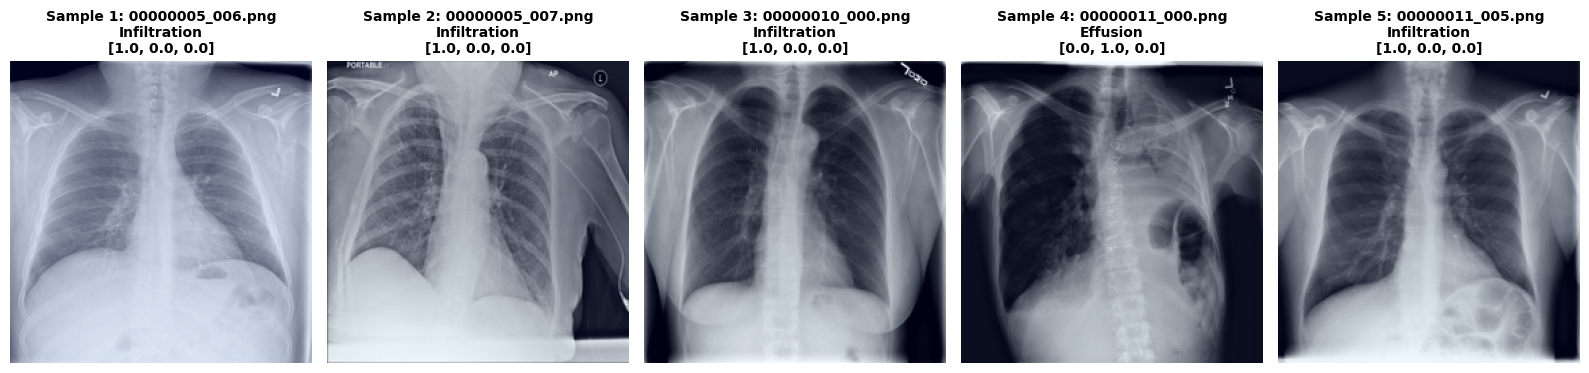

In [1]:
import utils.models
import utils.utils
import utils.dataset
import pathlib
import yaml

utils.utils.set_random_seeds(seed=42)
with open("data/cxr_dataset.yaml", "r") as f:
    cfg = yaml.safe_load(f)
image_root = pathlib.Path(cfg['image_root'])

# Loading a model.
model_name                           = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224' # or 'hf-hub:luhuitong/CLIP-ViT-L-14-448px-MedICaT-ROCO'
model, preprocess, tokenizer, device = utils.models.load_clip_model(model_name      = model_name, freeze_backbone = True)

# Load dataset splits
train_df, train_paths, train_labels = utils.dataset.load_split(cfg['train_csv'], image_root, verbose=True)
valid_df, valid_paths, valid_labels = utils.dataset.load_split(cfg['valid_csv'], image_root)
test_df,  test_paths,  test_labels  = utils.dataset.load_split(cfg['test_csv'],  image_root)

# filtering
train_df_filtered, train_paths_filtered = utils.dataset.filter_dataset(train_df, train_paths, cfg['top_labels'], cfg['all_labels'])
valid_df_filtered, valid_paths_filtered = utils.dataset.filter_dataset(valid_df, valid_paths, cfg['top_labels'], cfg['all_labels'])
test_df_filtered,  test_paths_filtered  = utils.dataset.filter_dataset(test_df,  test_paths,  cfg['top_labels'], cfg['all_labels'])
labels                                  = train_df_filtered[cfg['top_labels']].values.astype('float32')

# Package the filtered datasets into clean dictionaries
paths_dict = {'train': train_paths_filtered, 'valid': valid_paths_filtered, 'test' : test_paths_filtered}
df_dict    = {'train': train_df_filtered,    'valid': valid_df_filtered,    'test' : test_df_filtered}

# Create PyTorch DataLoaders
train_loader, valid_loader, test_loader = utils.dataset.create_dataloaders(paths_dict  = paths_dict, 
                                                                           df_dict     = df_dict, 
                                                                           top_labels  = cfg['top_labels'], 
                                                                           preprocess  = preprocess, 
                                                                           batch_size  = 16,
                                                                           num_workers = 2)
# verifying.
utils.dataset.inspect_dataloader(train_loader, class_names=cfg['top_labels'], num_images=5)

# Train
We can run it in terminal.

In [ ]:
!python train.py